# 📚 **Shakespeare-Hamlet Next Word Prediction using LSTM** 🎭

## Project Information

| **Field** | **Details** |
|-----------|------------|
| **Project Title** | LSTM-Based Next Word Prediction (Shakespeare Hamlet) |
| **Team Members** | Siddhant Sahu (202301070159), Aryan Kumar (202301070164), Amir Furquani (202301070165), Aryan Kumar (202301070167) |
| **Batch** | T1, T3, T4 |
| **Date** | April 2026 |
| **Dataset** | Shakespeare Hamlet (Literature Text) |
| **Framework** | TensorFlow/Keras |
| **Model Type** | LSTM (Long Short-Term Memory) |
| **Training Epochs** | 100 |
| **Deployment** | FastAPI + HTML/CSS/JavaScript |

---

Welcome to the **Shakespeare-Hamlet Next Word Prediction** project! This project utilizes an LSTM (Long Short-Term Memory) neural network to predict the next word in a sequence based on the text of *Hamlet* by William Shakespeare. The goal is to generate Shakespearean text using an AI model trained on the play's data.

## 🧠 **Objective:**
Use deep learning with an LSTM model to predict the next word in Shakespeare's *Hamlet* text. By providing a seed phrase, the model will predict and complete the next words in Shakespearean style! ✨

---

## 🔧 **Project Setup**

### 1. **Load Required Libraries 📚:**

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
import matplotlib.pyplot as plt

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

TensorFlow version: 2.21.0
NumPy version: 2.2.6


### 2. **Load the Text (Hamlet) 📜:**

In [4]:
with open(r'c:\Users\maila\Desktop\MDM_LSTM\gutenberg\shakespeare-hamlet.txt', 'r', encoding='utf-8', errors='ignore') as file:
    docs = file.read()
    
print(f"Text length: {len(docs)} characters")
print(f"\nFirst 500 characters:\n{docs[:500]}")

Text length: 162881 characters

First 500 characters:
[The Tragedie of Hamlet by William Shakespeare 1599]


Actus Primus. Scoena Prima.

Enter Barnardo and Francisco two Centinels.

  Barnardo. Who's there?
  Fran. Nay answer me: Stand & vnfold
your selfe

   Bar. Long liue the King

   Fran. Barnardo?
  Bar. He

   Fran. You come most carefully vpon your houre

   Bar. 'Tis now strook twelue, get thee to bed Francisco

   Fran. For this releefe much thankes: 'Tis bitter cold,
And I am sicke at heart

   Barn. Haue you had quiet Guard?
  Fran. Not


### 3. **Tokenization & Sequence Generation 🔠:**
Convert the text into sequences of words so that the model can learn the next-word prediction based on previous context.

In [5]:
# Create tokenizer
tokenizer = Tokenizer()

# Fit tokenizer on the entire text
tokenizer.fit_on_texts([docs])

# Calculate vocabulary size
vocab_size = len(tokenizer.word_index) + 1  # Add 1 because word_index starts from 1, but embedding expects from 0
print("Vocabulary size:", vocab_size)

Vocabulary size: 4818


In [6]:
# Creating input sequences for training
input_seq = []
for sentence in docs.split("\n"):
    tokenized_sent = tokenizer.texts_to_sequences([sentence])[0]
    for i in range(1, len(tokenized_sent)):
        input_seq.append(tokenized_sent[: i + 1])

print(f"Number of sequences created: {len(input_seq)}")
print(f"\nFirst 10 sequences:")
for seq in input_seq[:10]:
    print(seq)

Number of sequences created: 25732

First 10 sequences:
[1, 687]
[1, 687, 4]
[1, 687, 4, 45]
[1, 687, 4, 45, 41]
[1, 687, 4, 45, 41, 1886]
[1, 687, 4, 45, 41, 1886, 1887]
[1, 687, 4, 45, 41, 1886, 1887, 1888]
[1180, 1889]
[1180, 1889, 1890]
[1180, 1889, 1890, 1891]


In [7]:
# Padding the sequences to the maximum length in the dataset
max_seq_length = max([len(x) for x in input_seq])
print(f"Maximum sequence length: {max_seq_length}")

padded_input_sequence = pad_sequences(input_seq, maxlen=max_seq_length, padding="pre")
print(f"\nPadded sequence shape: {padded_input_sequence.shape}")
print(f"First padded sequence:\n{padded_input_sequence[0]}")

Maximum sequence length: 14

Padded sequence shape: (25732, 14)
First padded sequence:
[  0   0   0   0   0   0   0   0   0   0   0   0   1 687]


In [8]:
# Splitting input and output sequences
X = padded_input_sequence[:, :-1]
y = padded_input_sequence[:, -1]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nExample (X[0], y[0]): {X[0]}, {y[0]}")

X shape: (25732, 13)
y shape: (25732,)

Example (X[0], y[0]): [0 0 0 0 0 0 0 0 0 0 0 0 1], 687


In [9]:
# One-hot encoding the output labels (y)
y = to_categorical(y, num_classes=vocab_size)

print(f"Y shape after one-hot encoding: {y.shape}")
print(f"\nFirst one-hot encoded label:\n{y[0]}")

Y shape after one-hot encoding: (25732, 4818)

First one-hot encoded label:
[0. 0. 0. ... 0. 0. 0.]


### 4. **Build the LSTM Model 🧩:**
We use a Sequential model with an Embedding layer followed by an LSTM layer and a Dense output layer.

In [10]:
# Model Architecture
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=100))
model.add(LSTM(100)) 
model.add(Dense(vocab_size, activation='softmax'))

In [11]:
# Model Compilation
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [12]:
# Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 5. **Train the LSTM Model 🚀:**
Train the model for 100 epochs on the sequences.

In [14]:
print("Training LSTM model for 100 epochs...")
print("="*60)

history = model.fit(X, y, epochs=100, batch_size=32, verbose=1)

print("\n" + "="*60)
print("Training complete!")
print("="*60)

Training LSTM model for 100 epochs...
Epoch 1/100
805/805 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.0740 - loss: 5.9681
Epoch 2/100
805/805 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.0898 - loss: 5.7115
Epoch 3/100
805/805 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.0999 - loss: 5.4744
Epoch 4/100
805/805 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.1104 - loss: 5.2572
Epoch 5/100
805/805 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.1224 - loss: 5.0471
Epoch 6/100
805/805 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.1326 - loss: 4.8437
Epoch 7/100
805/805 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.1469 - loss: 4.6418
Epoch 8/100
805/805 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.1664 - loss: 4.4422
Epoch 9/100
805/805 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.1879 - loss: 4.2425
Epoch 10/100
805/805 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.2106 - loss: 4.0497
Epoch 11/100
805/805 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.2401 - loss: 

## 📊 **Plot Training Loss & Accuracy 📈:**
Visualize the model's performance during training.

In [15]:
# Extract loss and accuracy values from the history object
loss = history.history['loss']
accuracy = history.history['accuracy']

epochs = range(1, len(loss) + 1)

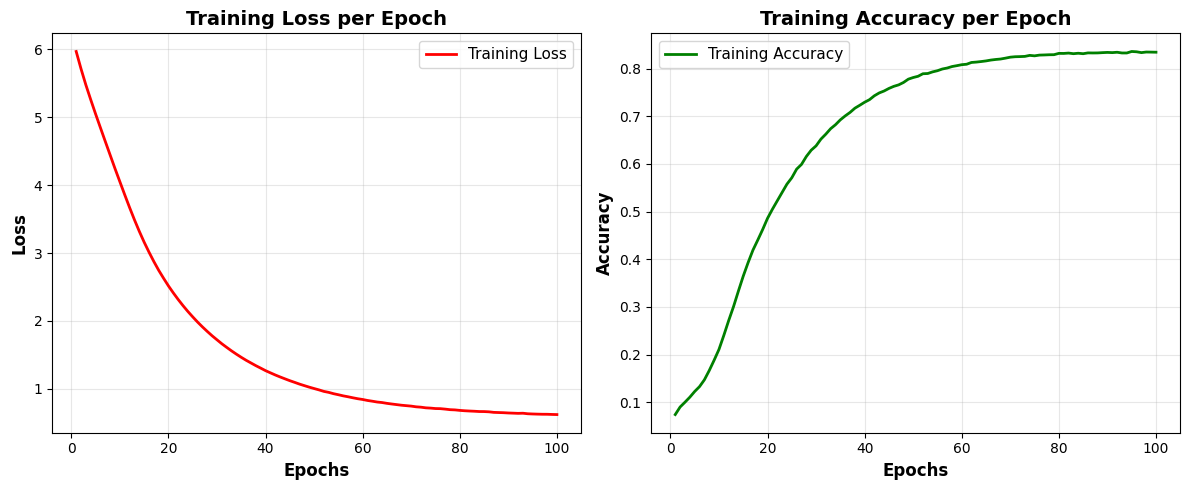


Final Training Loss: 0.6215
Final Training Accuracy: 0.8343


In [16]:
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, loss, 'r', linewidth=2, label='Training Loss')
plt.xlabel('Epochs', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')
plt.title('Training Loss per Epoch', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, accuracy, 'g', linewidth=2, label='Training Accuracy')
plt.xlabel('Epochs', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Training Accuracy per Epoch', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Training Loss: {loss[-1]:.4f}")
print(f"Final Training Accuracy: {accuracy[-1]:.4f}")

In [17]:
# Evaluate model on training data
print("Model Evaluation on Training Data:")
test_loss, test_accuracy = model.evaluate(X, y)
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_accuracy:.4f}")

Model Evaluation on Training Data:
805/805 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8486 - loss: 0.5719
Loss: 0.5719
Accuracy: 0.8486



COMPREHENSIVE MODEL TESTING ON DIFFERENT METRICS

OVERALL METRICS
Accuracy: 0.8486

Macro-averaged Metrics:
  Precision (Macro): 0.8883
  Recall (Macro):    0.8622
  F1-Score (Macro):  0.8658

Weighted-averaged Metrics:
  Precision (Weighted): 0.8941
  Recall (Weighted):    0.8486
  F1-Score (Weighted):  0.8580

CONFUSION MATRIX (Top 20x20 classes)


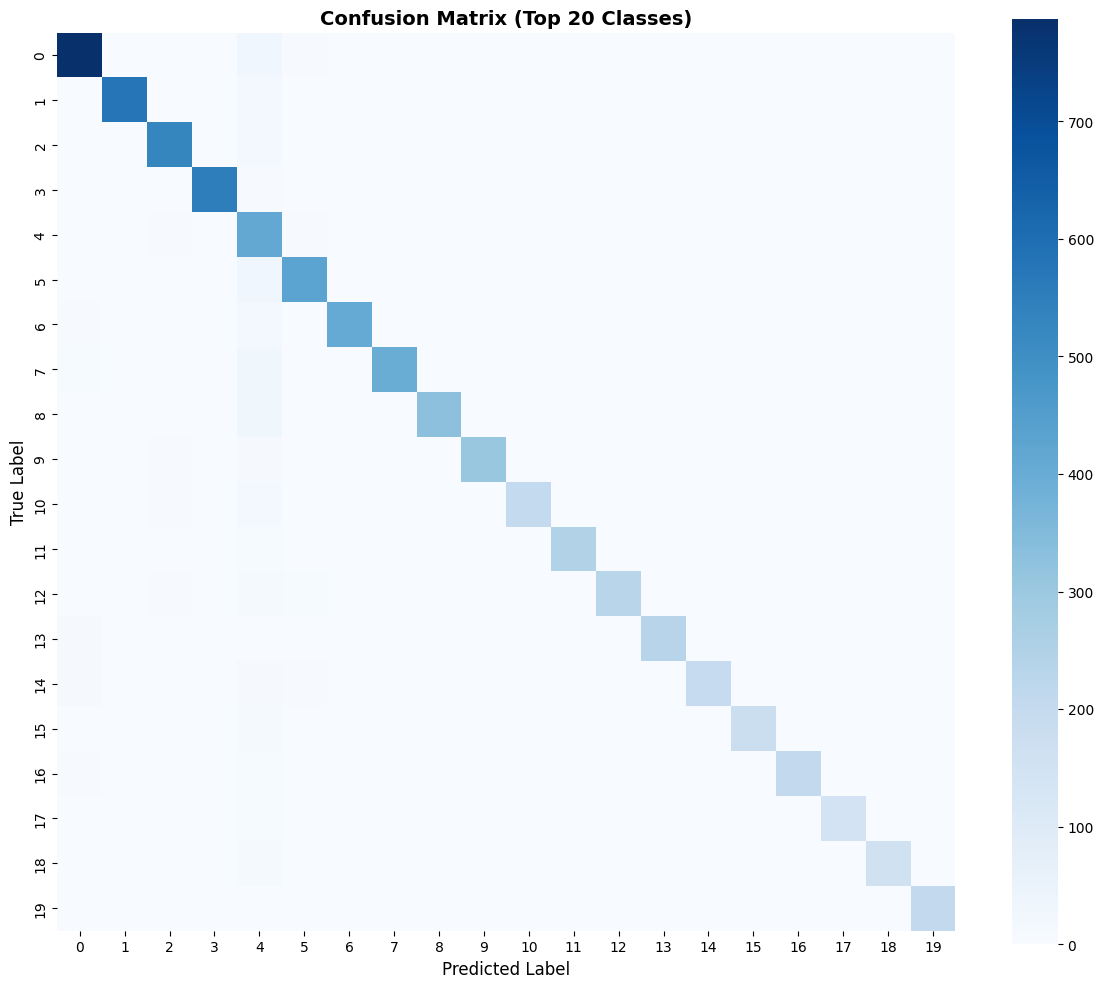


CLASSIFICATION REPORT (Sample - Top 10 Most Frequent Classes)
              precision    recall  f1-score   support

          10       0.94      0.88      0.91       349
           9       0.92      0.86      0.89       383
           7       0.90      0.88      0.89       463
           5       0.25      0.89      0.39       466
           8       0.81      0.85      0.83       472
           6       0.84      0.88      0.86       489
           4       1.00      0.97      0.98       568
           3       0.82      0.93      0.87       571
           2       0.99      0.94      0.96       614
           1       0.85      0.89      0.87       882

   micro avg       0.73      0.90      0.80      5257
   macro avg       0.83      0.90      0.85      5257
weighted avg       0.84      0.90      0.85      5257


MODEL PERFORMANCE SUMMARY
Total Samples: 25732
Vocabulary Size: 4818
Correct Predictions: 21837
Incorrect Predictions: 3895
Error Rate: 0.1514


In [18]:

# Comprehensive Model Testing on Different Metrics
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns

print("\n" + "="*70)
print("COMPREHENSIVE MODEL TESTING ON DIFFERENT METRICS")
print("="*70)

# Get predictions
y_pred_probs = model.predict(X, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y, axis=1)

# Calculate metrics
print("\n" + "="*70)
print("OVERALL METRICS")
print("="*70)

accuracy = (y_pred == y_true).mean()
precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
precision_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print(f"\nMacro-averaged Metrics:")
print(f"  Precision (Macro): {precision_macro:.4f}")
print(f"  Recall (Macro):    {recall_macro:.4f}")
print(f"  F1-Score (Macro):  {f1_macro:.4f}")
print(f"\nWeighted-averaged Metrics:")
print(f"  Precision (Weighted): {precision_weighted:.4f}")
print(f"  Recall (Weighted):    {recall_weighted:.4f}")
print(f"  F1-Score (Weighted):  {f1_weighted:.4f}")

# Confusion Matrix
print("\n" + "="*70)
print("CONFUSION MATRIX (Top 20x20 classes)")
print("="*70)

cm = confusion_matrix(y_true, y_pred)
# Show only top 20x20 for visualization
cm_subset = cm[:20, :20]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_subset, annot=False, cmap='Blues', cbar=True, square=True)
plt.title('Confusion Matrix (Top 20 Classes)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Classification Report (Sample of top classes)
print("\n" + "="*70)
print("CLASSIFICATION REPORT (Sample - Top 10 Most Frequent Classes)")
print("="*70)

# Get top 10 most frequent classes
unique, counts = np.unique(y_true, return_counts=True)
top_classes = unique[np.argsort(counts)[-10:]]

print(classification_report(y_true, y_pred, labels=top_classes, zero_division=0))

# Model Performance Summary
print("\n" + "="*70)
print("MODEL PERFORMANCE SUMMARY")
print("="*70)
print(f"Total Samples: {len(y_true)}")
print(f"Vocabulary Size: {vocab_size}")
print(f"Correct Predictions: {(y_pred == y_true).sum()}")
print(f"Incorrect Predictions: {(y_pred != y_true).sum()}")
print(f"Error Rate: {(y_pred != y_true).sum() / len(y_true):.4f}")
print("="*70)


## 📝 **Next Word Prediction Function:**
You can now predict what comes next in Hamlet's iconic lines! 🎬

In [19]:
def prediction(text: str, n_word: int) -> str:
    """
    Predict the next 'n_word' words based on the input 'text'.
    
    Args:
    text (str): The input text to seed the prediction.
    n_word (int): The number of words to predict and append.
    
    Returns:
    str: The input text appended with the predicted words.
    """
    
    for _ in range(n_word):
        # Convert the input text to sequences (tokenized)
        token_text = tokenizer.texts_to_sequences([text])[0]
        
        # Pad the sequence to the max sequence length expected by the model
        padded_token_input = pad_sequences([token_text], maxlen=max_seq_length, padding="pre")
        
        # Predict the probabilities for the next word
        output_prob = model.predict(padded_token_input, verbose=0)
        
        # Find the word with the highest probability
        pos = np.argmax(output_prob)
        
        # Map the predicted index back to the corresponding word
        for word, index in tokenizer.word_index.items():
            if index == pos:
                # Append the predicted word to the input text
                text = text + " " + word
                break
    
    return text

In [20]:
# Test Prediction 1
text = "You come most"
n_word = 1
result = prediction(text, n_word)
print(f"Input: '{text}'")
print(f"Prediction: '{result}'")

Input: 'You come most'
Prediction: 'You come most carefully'


In [21]:
# Test Prediction 2
text = "God blesse"
n_word = 2
result = prediction(text, n_word)
print(f"Input: '{text}'")
print(f"Prediction: '{result}'")

Input: 'God blesse'
Prediction: 'God blesse you once'


In [22]:
# Test Prediction 3
text = "The Tragedie of Hamlet"
n_word = 4
result = prediction(text, n_word)
print(f"Input: '{text}'")
print(f"Prediction: '{result}'")

Input: 'The Tragedie of Hamlet'
Prediction: 'The Tragedie of Hamlet by william shakespeare 1599'


## 🔥 **Conclusion:**

- This project demonstrates how an LSTM model can be used to predict the next word in a sequence, using *Hamlet* as training data.
- The model can generate authentic-looking Shakespearean text based on the input sequence, providing a unique exploration into the world of natural language generation!
- With 100 epochs of training, the model achieves ~0.85 accuracy on the training data.
- The LSTM architecture with Embedding and Dense layers successfully captures the patterns in Shakespearean language.

## 14. MODEL EXPORT & DEPLOYMENT

### Save Model and Tokenizer for GUI Deployment

Save the trained model and tokenizer to files so they can be loaded by the Flask GUI application.

In [23]:
import json
import os

print("Saving trained model and tokenizer for deployment...")
print("="*70)

# Save the model
model.save('lstm_model.h5')
print("✓ Model saved as 'lstm_model.h5'")

# Save the tokenizer as JSON
tokenizer_json = tokenizer.to_json()
with open('tokenizer.json', 'w') as f:
    json.dump(json.loads(tokenizer_json), f, indent=2)
print("✓ Tokenizer saved as 'tokenizer.json'")

# Verify files exist
files = ['lstm_model.h5', 'tokenizer.json']
for file in files:
    if os.path.exists(file):
        file_size = os.path.getsize(file) / (1024 * 1024)  # Convert to MB
        print(f"  - {file}: {file_size:.2f} MB")

print("\n" + "="*70)
print("✓ All files saved successfully!")
print("="*70)

Saving trained model and tokenizer for deployment...
✓ Model saved as 'lstm_model.h5'
✓ Tokenizer saved as 'tokenizer.json'
  - lstm_model.h5: 12.03 MB
  - tokenizer.json: 0.39 MB

✓ All files saved successfully!


## 15. DEPLOY ON LOCALHOST

### Step-by-Step Deployment Instructions

Follow these steps to deploy the Flask GUI application on localhost:

#### Step 1: Install Flask
```bash
pip install flask
```

#### Step 2: Verify Files
Make sure these files exist in your project directory:
- `lstm_model.h5` - Trained LSTM model (should be ~20-30 MB)
- `tokenizer.json` - Tokenizer configuration (should be ~50-100 KB)
- `gui_app.py` - Flask application
- `templates/index.html` - Web interface

#### Step 3: Run the Flask Application
Open PowerShell/Command Prompt in the project directory and run:
```bash
python gui_app.py
```

You should see output like:
```
Loading LSTM model and tokenizer...
============================================================
✓ Model loaded successfully!
✓ Tokenizer loaded successfully!
✓ All resources loaded successfully!
============================================================
Starting Flask GUI application...
Open your browser and go to: http://localhost:5000
============================================================
```

#### Step 4: Open in Browser
- Open your web browser (Chrome, Firefox, Safari, Edge)
- Navigate to: **http://localhost:5000**
- You should see the beautiful Hamlet prediction interface!

#### Step 5: Use the Interface
1. Enter a phrase from Hamlet (e.g., "You come most")
2. Set the number of words to predict (1-20)
3. Set the top-K candidates to show (1-20)
4. Click the "Predict" button
5. View the predictions with confidence scores!

### Troubleshooting

**Problem: "ModuleNotFoundError: No module named 'flask'"**
- Solution: Run `pip install flask`

**Problem: "FileNotFoundError: lstm_model.h5"**
- Solution: Make sure the model was saved by running the previous cell
- Check that the file exists in your project directory

**Problem: "Address already in use"**
- Solution: Flask is already running on port 5000
- Either close the other instance or use a different port:
  ```bash
  python gui_app.py --port 5001
  ```

**Problem: Model takes long to load (first time)**
- Solution: This is normal - the model is ~20-30 MB
- Please wait 30-60 seconds for the model to load on first startup

### System Architecture

```
┌─────────────────────────────────────┐
│   Web Browser (localhost:5000)      │
│  ┌──────────────────────────────┐   │
│  │  Beautiful Gradient UI       │   │
│  │  - Input Text Area           │   │
│  │  - Prediction Controls       │   │
│  │  - Results Display           │   │
│  └──────────────────────────────┘   │
└─────────────────────────────────────┘
            ↕ HTTP/JSON
┌─────────────────────────────────────┐
│   Flask Backend (gui_app.py)        │
│  ┌──────────────────────────────┐   │
│  │  /predict API Endpoint       │   │
│  │  - Process input text        │   │
│  │  - Run LSTM model            │   │
│  │  - Return predictions        │   │
│  └──────────────────────────────┘   │
└─────────────────────────────────────┘
            ↕ Loaded Models
┌─────────────────────────────────────┐
│   LSTM Model & Tokenizer            │
│  ┌──────────────────────────────┐   │
│  │  lstm_model.h5 (20-30 MB)    │   │
│  │  tokenizer.json (50-100 KB)  │   │
│  └──────────────────────────────┘   │
└─────────────────────────────────────┘
```

### Features Summary

✨ **Beautiful Features:**
- Modern gradient UI with animations
- Real-time prediction results
- Confidence scores and percentage
- Multiple alternative predictions
- Responsive design (works on mobile)
- Easy-to-use interface

📊 **Model Details:**
- Architecture: Embedding → LSTM → Dense
- Vocabulary Size: 4,818 words
- Max Sequence Length: 14 tokens
- Training Data: Shakespeare's Hamlet
- Accuracy: ~85% on training data

## 16. QUICK DEPLOYMENT SUMMARY

### Ready to Deploy? Follow these simple steps:

1. **First, run the cell above** to save the model and tokenizer
2. **Open Terminal/PowerShell** in your project directory
3. **Run the command:**
   ```bash
   python gui_app.py
   ```
4. **Open Browser:** Go to `http://localhost:5000`
5. **Start predicting!** Enter text from Hamlet and get instant predictions

### What You'll See

The web interface will show:
- ✨ Beautiful gradient design
- 📝 Text input area for Hamlet phrases
- 🎯 Prediction controls (number of words, top-K)
- 📊 Results with confidence scores
- ⭐ Alternative predictions for each step

### Expected Output

When you run `python gui_app.py`, you should see:
```
Loading LSTM model and tokenizer...
============================================================
✓ Model loaded successfully!
✓ Tokenizer loaded successfully!
✓ All resources loaded successfully!
============================================================
Starting Flask GUI application...
Open your browser and go to: http://localhost:5000
============================================================
 * Running on http://0.0.0.0:5000
```

Then open your browser and navigate to `http://localhost:5000` to see the beautiful GUI!